## Feature Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# best to do after train test split/ if not then do on specific column by creating tehir dataframes

scaler.fit(X_train)  # take df as input but returns numpy array

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

Best time to use Standadization :

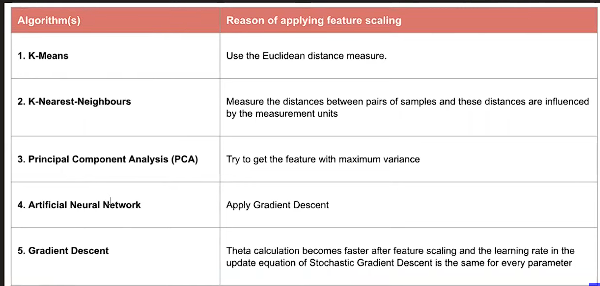

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.preprocessing import OrdinalEncoder

oe = OrdinalEncoder(categories=[['Poor','Average','Good'],['School','UG','PG']])

oe.fit(X_train)

# fiting in train but transform both train and test

X_train_encoded = oe.transform(X_train)
X_test_encoded = oe.transform(X_test))

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

le.fit(y_train)

y_train = le.transform(y_train)
y_test = le.transform(y_test)

In [ ]:
from sklearn.preprocessing import FunctionTransformer

trf = FunctionTransformer(func=np.log1p)

In [ ]:
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method='box-cox') # method can be box-cox or yeo-johnson. box-cox only works for positive data but yeo-johnson works for both positive and negative data
X_transformed = pt.fit_transform(X+0.0000001)

In [ ]:
from sklearn.preprocessing import KBinsDiscretizer

kbin_age = KBinsDiscretizer(n_bins=15,encode='ordinal',strategy='quantile')
kbin_fare = KBinsDiscretizer(n_bins=15,encode='ordinal',strategy='quantile')

In [ ]:
from sklearn.preprocessing import Binarizer

trf = ColumnTransformer([
    ('bin',Binarizer(copy=False),['family']) # copy false means it will do inplace transformation and return the same array with transformed values. if true then it will return a new array with transformed values and original array will remain unchanged
],remainder='passthrough')

In [ ]:
IF MIXED VARIABLE THEN SEPARATE THE NUM AND ALPHA

In [ ]:
df['number_numerical'] = pd.to_numeric(df["number"], errors='coerce', downcast='integer')
df['ticket_num'] = pd.to_numeric(df['ticket_num'], errors='coerce', downcast='integer')

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline,make_pipeline
from sklearn import set_config
set_config(display='diagram')

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.tree import DecisionTreeClassifier

transformer1 = ColumnTransformer(transformers=[
    ('tnf1',SimpleImputer(),['fever']),
    ('tnf2',OrdinalEncoder(categories=[['Mild','Strong']]),['cough']),
    ('tnf3',OneHotEncoder(sparse=False,drop='first'),['gender','city'])
],remainder='passthrough')

transformer2 = DecisionTreeClassifier()

pipe = Pipeline([
    ('transformer1',transformer1),
    ('transformer2',transformer2),
])
# or 
pipe = make_pipeline(transformer1,transformer2)

pipe.fit(X_train,y_train)

y_pred = pipe.predict(X_test)

# export 
import pickle
pickle.dump(pipe,open('pipe.pkl','wb'))

In [ ]:
from sklearn.model_selection import cross_val_score
cross_val_score(pipe, X_train, y_train, cv=5, scoring='accuracy').mean()

In [ ]:
from sklearn.model_selection import GridSearchCV
grid = GridSearchCV(pipe, params, cv=5, scoring='accuracy')
grid.fit(X_train, y_train)

grid.best_score_,grid.best_params_

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression

numerical_features = ['Age', 'Fare']
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_features = ['Embarked', 'Sex']
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe',OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression())
])

param_grid = {
    'preprocessor__num__imputer__strategy': ['mean', 'median'],
    'preprocessor__cat__imputer__strategy': ['most_frequent', 'constant'],
    'classifier__C': [0.1, 1.0, 10, 100]
}

grid_search = GridSearchCV(clf, param_grid, cv=10)

grid_search.fit(X_train, y_train)

print(f"Best params:")
print(grid_search.best_params_)

print(f"Internal CV score: {grid_search.best_score_:.3f}")


cv_results = pd.DataFrame(grid_search.cv_results_)
cv_results = cv_results.sort_values("mean_test_score", ascending=False)
cv_results[['param_classifier__C','param_preprocessor__cat__imputer__strategy','param_preprocessor__num__imputer__strategy','mean_test_score']]

# Working with Dates

In [ ]:
# Converting to datetime datatype
date['date'] = pd.to_datetime(date['date'])

In [ ]:
#EXTRACTING YEAR, MONTH, DAY FROM DATE

date['date_year'] = date['date'].dt.year
date['date_month'] = date['date'].dt.month
date['date_day'] = date['date'].dt.day

In [ ]:
#`EXTRACTING MONTH NAME AND DAY NAME FROM DATE`

date['date_month_name'] = date['date'].dt.month_name()
date['date_day_name'] = date['date'].dt.day_name()


date['date_dow'] = date['date'].dt.dayofweek
date['date_doy'] = date['date'].dt.dayofyear
date['date_quarter'] = date['date'].dt.quarter

In [ ]:
# Creating a new column to check if the date is weekend or not

date['date_is_weekend'] = np.where(date['date_dow_name'].isin(['Sunday', 'Saturday']), 1,0)


In [ ]:
# Extracting week number and week of year from date

date['date_week'] = date['date'].dt.week
date['date_weekofyear'] = date['date'].dt.weekofyear


## missing  data

In [ ]:
from sklearn.impute import SimpleImputer

#strategy can be mean, median, most_frequent, constant
imputer1 = SimpleImputer(strategy='median') 
imputer2 = SimpleImputer(strategy='mean')

trf = ColumnTransformer([
    ('imputer1',imputer1,['Age']),
    ('imputer2',imputer2,['Fare'])
],remainder='passthrough')

trf.fit_transform(X_train)

trf.transform(X_test)

In [ ]:
from sklearn.impute import KNNImputer

knn = KNNImputer(n_neighbors=3,weights='distance')#weights can be uniform or distance. uniform means all neighbors will have equal weightage and distance means closer neighbors will have more weightage

X_train_trf = knn.fit_transform(X_train)
X_test_trf = knn.transform(X_test)

## outlier


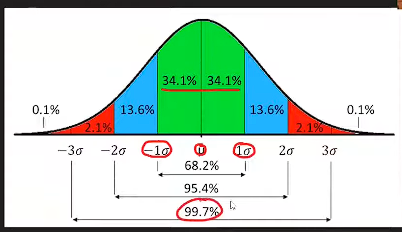

In [ ]:
percentile25 = df['placement_exam_marks'].quantile(0.25)
percentile75 = df['placement_exam_marks'].quantile(0.75)

iqr=percentile75 - percentile25

upper_limit = percentile75 + 1.5 * iqr
lower_limit = percentile25 - 1.5 * iqr

In [ ]:
upper_limit = df['Height'].quantile(0.99)
lower_limit = df['Height'].quantile(0.01)

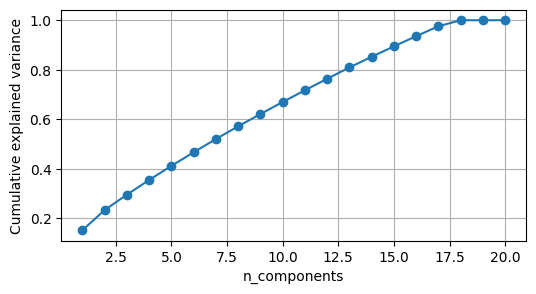

n_components to retain 95% variance: 17
Best params (by CV): {'clf__C': 0.01, 'pca__n_components': 20}
CV best score: 0.8200
Test set score using best params: 0.8150


In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

import matplotlib.pyplot as plt


# create dummy dataset
X, y = make_classification(n_samples=1000, n_features=20, n_informative=5, n_redundant=2, random_state=42)

# train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 1) Simple PCA fit and explained variance plot
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)

pca_full = PCA(n_components=X_train_s.shape[1])
pca_full.fit(X_train_s)

cum_var = np.cumsum(pca_full.explained_variance_ratio_)
plt.figure(figsize=(6,3))
plt.plot(np.arange(1, len(cum_var)+1), cum_var, marker='o')
plt.xlabel('n_components'); plt.ylabel('Cumulative explained variance')
plt.grid(True)
plt.show()

# choose n_components to retain 95% variance
n_components_95 = int(np.searchsorted(cum_var, 0.95) + 1)
print(f"n_components to retain 95% variance: {n_components_95}")

# transform train/test using this n_components
pca = PCA(n_components=n_components_95)
X_train_pca = pca.fit_transform(X_train_s)
X_test_pca = pca.transform(scaler.transform(X_test))

# 2) Use GridSearchCV to choose best n_components based on downstream model performance
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA()),
    ('clf', LogisticRegression(max_iter=1000))
])

param_grid = {
    'pca__n_components': [2, 5, 8, 10, 12, 15, 20],
    'clf__C': [0.01, 0.1, 1, 10]
}

grid = GridSearchCV(pipe, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train, y_train)

print("Best params (by CV):", grid.best_params_)
print(f"CV best score: {grid.best_score_:.4f}")

# evaluate on test set
test_score = grid.score(X_test, y_test)
print(f"Test set score using best params: {test_score:.4f}")